## Load Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
data = pd.read_csv('./banking-data.csv')
# Convert the 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'])
# Set the 'Date' column as the index
data.set_index('Date', inplace=True)
data.sort_index(inplace=True)
# Extract the 'Close' price as a numpy array
# log return 
price = data['Close'].dropna()
log_ret = np.log(price / price.shift(1)).dropna()
r = log_ret.values
T = len(r)


## Exploratory Data Analysis

###  Distributional & Higher-Moment Diagnostics
- **Descriptive Summary Statistics**: Calculate the exact sample mean, variance, skewness, and excess kurtosis of the log returns.

- **Normality Rejecting Tests**: Run formal statistical tests such as the Jarque-Bera and Shapiro-Wilk tests to prove the non-normality of your NEPSE banking data.

- **Empirical Density vs. Gaussian Overlay**: Plot a frequency histogram against a theoretical normal distribution to visually capture the leptokurtic peak and fat tails.

- **Normal Quantile-Quantile (Q-Q) Plot**: Map your sample quantiles against theoretical normal quantiles to isolate exactly where the tail deviations and jump anomalies begin.


       HIGHER-MOMENT STATISTICAL SUMMARY
  Mean (Daily)        : 0.000424 (0.0424%)
  Variance (Daily)    : 0.000235
  Std. Deviation      : 0.015321 (1.5321%)
  Skewness            : 0.9029
  Excess Kurtosis     : 7.2073
--------------------------------------------------
            FORMAL HYPOTHESIS TESTING
--------------------------------------------------
  Jarque-Bera Test    : Stat = 7981.75, p-value = 0.0000e+00
  Shapiro-Wilk Test   : Stat = 0.8919, p-value = 4.1100e-44
  CRITICAL VERIFICATION: Strict non-normality confirmed ($p < 0.05$).
  The returns show heavy-tailed/asymmetric jump dynamics.



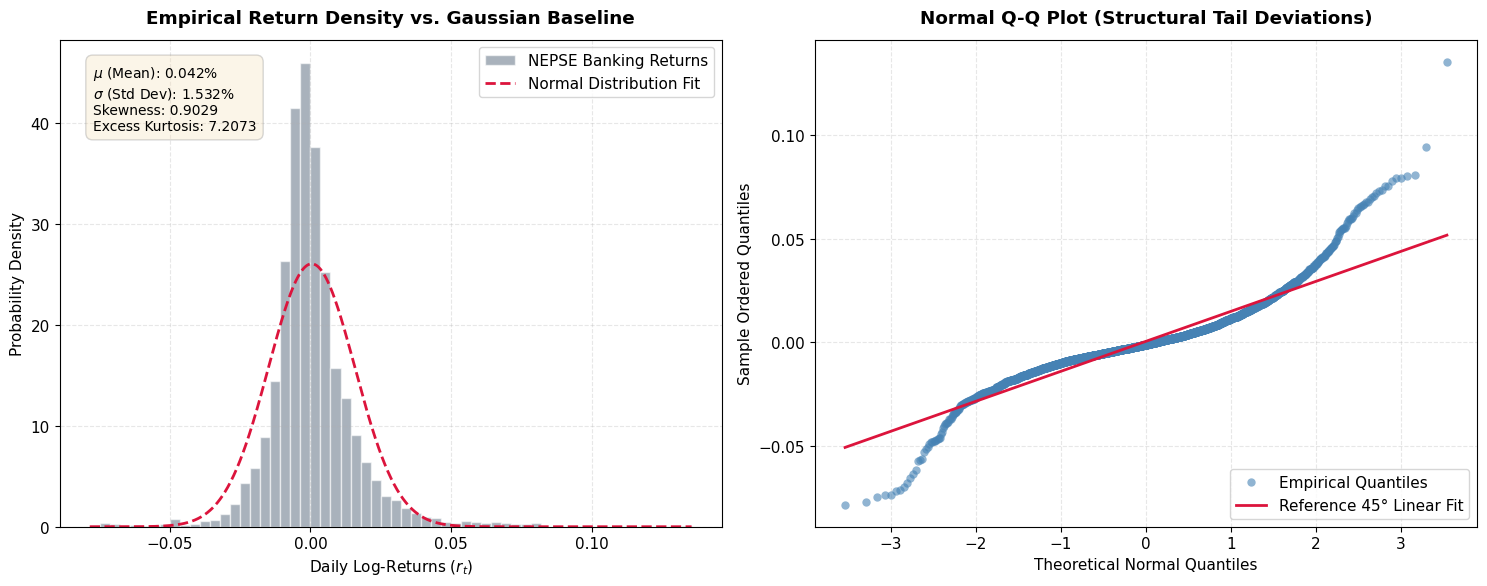

In [2]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. Distributional & Higher-Moment Calculations
# ==========================================
mean_r = np.mean(r)
var_r = np.var(r)
std_r = np.std(r)
skew_r = stats.skew(r)
kurt_r = stats.kurtosis(r)  # Pearson's definition: excess kurtosis (Normal = 0)

# ==========================================
# 2. Normality Rejecting Tests
# ==========================================
jb_stat, jb_pvalue = stats.jarque_bera(r)
sw_stat, sw_pvalue = stats.shapiro(r)

# Display a clean text summary matrix
print("\n" + "="*50)
print("       HIGHER-MOMENT STATISTICAL SUMMARY")
print("="*50)
print(f"  Mean (Daily)        : {mean_r:.6f} ({mean_r*100:.4f}%)")
print(f"  Variance (Daily)    : {var_r:.6f}")
print(f"  Std. Deviation      : {std_r:.6f} ({std_r*100:.4f}%)")
print(f"  Skewness            : {skew_r:.4f}")
print(f"  Excess Kurtosis     : {kurt_r:.4f}")
print("-"*50)
print("            FORMAL HYPOTHESIS TESTING")
print("-"*50)
print(f"  Jarque-Bera Test    : Stat = {jb_stat:.2f}, p-value = {jb_pvalue:.4e}")
print(f"  Shapiro-Wilk Test   : Stat = {sw_stat:.4f}, p-value = {sw_pvalue:.4e}")
print("="*50)

if jb_pvalue < 0.05 and sw_pvalue < 0.05:
    print("  CRITICAL VERIFICATION: Strict non-normality confirmed ($p < 0.05$).")
    print("  The returns show heavy-tailed/asymmetric jump dynamics.")
else:
    print("  WARNING: Failed to reject normality baseline.")
print("="*50 + "\n")

# ==========================================
# 3. Advanced Distributional Visualization Dashboard
# ==========================================
# Configure high-fidelity plot parameters
plt.rcParams.update({
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Subplot A: Empirical Density vs. Gaussian Overlay ---
# Empirical data histogram
n_bins = 60
axes[0].hist(r, bins=n_bins, density=True, alpha=0.6, color='slategray', edgecolor='white', label='NEPSE Banking Returns')

# Theoretical Normal Distribution fit overlay
x_grid = np.linspace(np.min(r), np.max(r), 1000)
gaussian_pdf = stats.norm.pdf(x_grid, loc=mean_r, scale=std_r)
axes[0].plot(x_grid, gaussian_pdf, color='crimson', linestyle='--', linewidth=2, label='Normal Distribution Fit')

# Informational metrics textbox overlay inside the chart area
metrics_box = '\n'.join((
    r'$\mu$ (Mean): ' + f'{mean_r*100:.3f}%',
    r'$\sigma$ (Std Dev): ' + f'{std_r*100:.3f}%',
    f'Skewness: {skew_r:.4f}',
    f'Excess Kurtosis: {kurt_r:.4f}'
))
props = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.3, edgecolor='gray')
axes[0].text(0.05, 0.95, metrics_box, transform=axes[0].transAxes, fontsize=10,
            verticalalignment='top', bbox=props)

axes[0].set_title('Empirical Return Density vs. Gaussian Baseline', fontweight='bold', pad=12)
axes[0].set_xlabel('Daily Log-Returns ($r_t$)')
axes[0].set_ylabel('Probability Density')
axes[0].legend(loc='upper right')

# --- Subplot B: Normal Quantile-Quantile (Q-Q) Plot ---
# Map empirical sample quantiles directly against mathematical normal theoretical quantiles
stats.probplot(r, dist="norm", plot=axes[1])

# Refine plot styling elements to match the theme
axes[1].get_lines()[0].set_markerfacecolor('steelblue')
axes[1].get_lines()[0].set_markeredgecolor('none')
axes[1].get_lines()[0].set_alpha(0.6)
axes[1].get_lines()[0].set_label('Empirical Quantiles')
axes[1].get_lines()[1].set_color('crimson')
axes[1].get_lines()[1].set_linewidth(2)
axes[1].get_lines()[1].set_label('Reference 45° Linear Fit')

axes[1].set_title('Normal Q-Q Plot (Structural Tail Deviations)', fontweight='bold', pad=12)
axes[1].set_xlabel('Theoretical Normal Quantiles')
axes[1].set_ylabel('Sample Ordered Quantiles')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Temporal Dependence & ARCH Effects (The GARCH Justification)
- **Autocorrelation (ACF) and Partial Autocorrelation (PACF) of Raw Returns**: Determine if your mean equation requires an autoregressive framework (e.g., ARMA parameters) or a simple constant drift.

- **ACF and PACF of Squared/Absolute Returns**: Check for long-memory patterns in variance to confirm that volatility is conditionally time-varying.

- **Ljung-Box Q-Test**: Run this formal test on both raw and squared returns to statistically reject the null hypothesis of independent and identically distributed (i.i.d.) white noise.

- **Engle’s ARCH LM Test**: Execute the Lagrange Multiplier test to confirm the presence of strong ARCH effects, establishing a firm baseline for your GARCH structure.

<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:46: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_10430/2981215808.py:46: SyntaxWarning: invalid escape sequence '\m'
  print("  → Mean Equation: Returns behave like un-correlated noise. A constant drift ($\mu$) is sufficient.")



          TEMPORAL DEPENDENCE & ARCH EFFECTS REPORT
  1. Ljung-Box Q-Test (Raw Returns - Mean Autocorrelation):
     Lag 10 Stat:  190.69  |  p-value: 1.4039e-35
     Lag 20 Stat:  208.99  |  p-value: 1.8613e-33
-----------------------------------------------------------------
  2. Ljung-Box Q-Test (Squared Returns - Volatility Memory):
     Lag 10 Stat: 2015.56  |  p-value: 0.0000e+00
     Lag 20 Stat: 2720.19  |  p-value: 0.0000e+00
-----------------------------------------------------------------
  3. Engle's ARCH Lagrange Multiplier (LM) Test:
     LM Test Statistic : 778.07
     p-value           : 1.0685e-160

  STRUCTURAL GARCH JUSTIFICATION:
  → CRITICAL VERIFICATION: Severe ARCH effects detected (p < 0.05).
    The constant variance assumption is violated; GARCH is mandatory.
  → Mean Equation: Serial dependence detected. An ARMA(p,q) mean baseline is required.



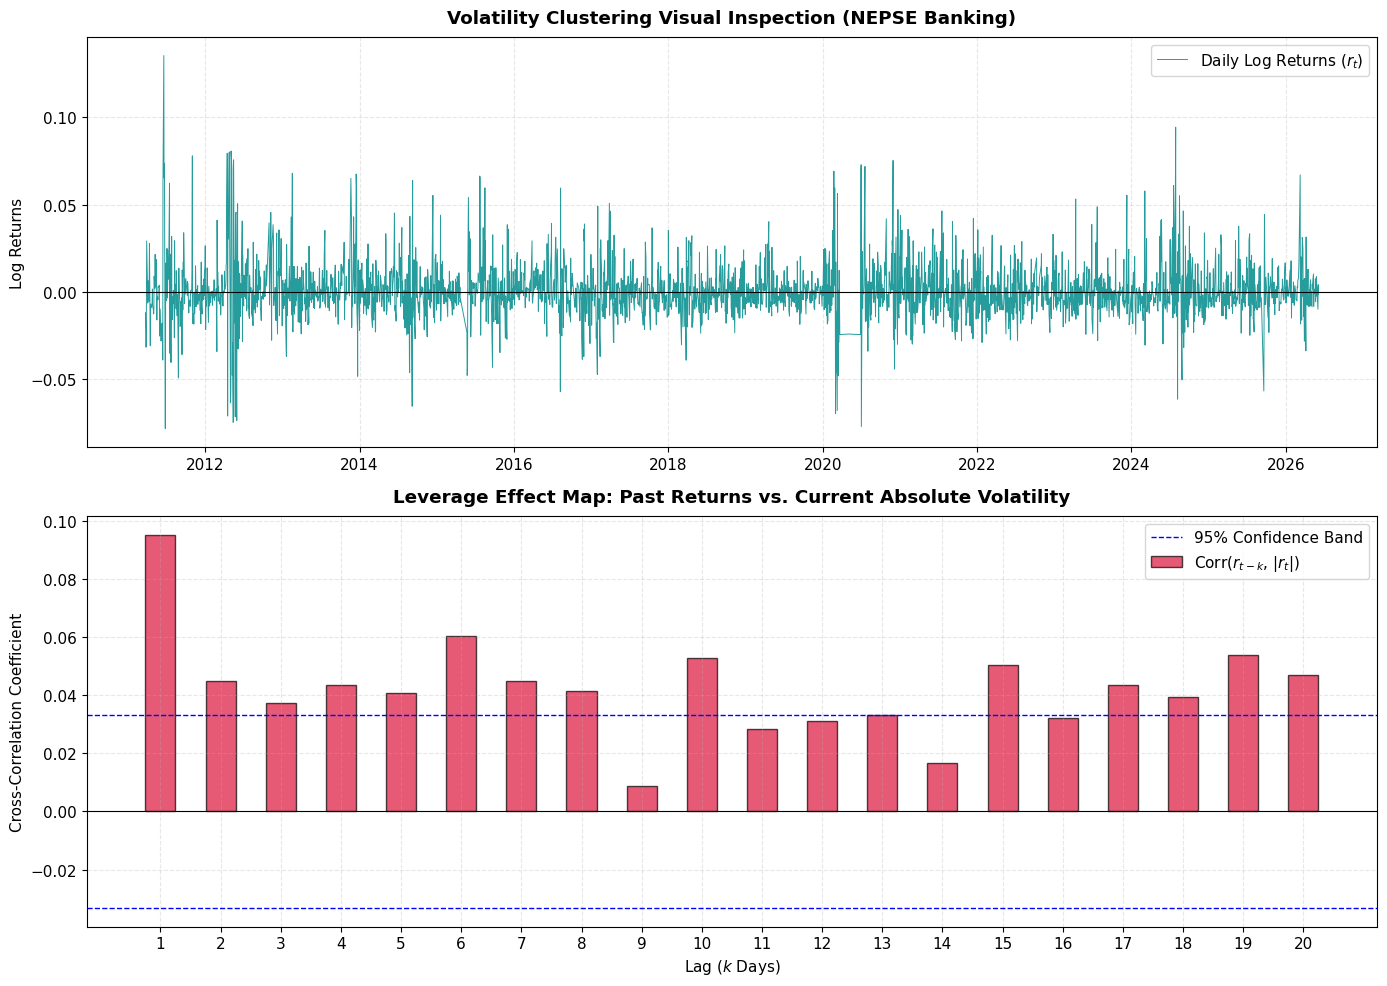

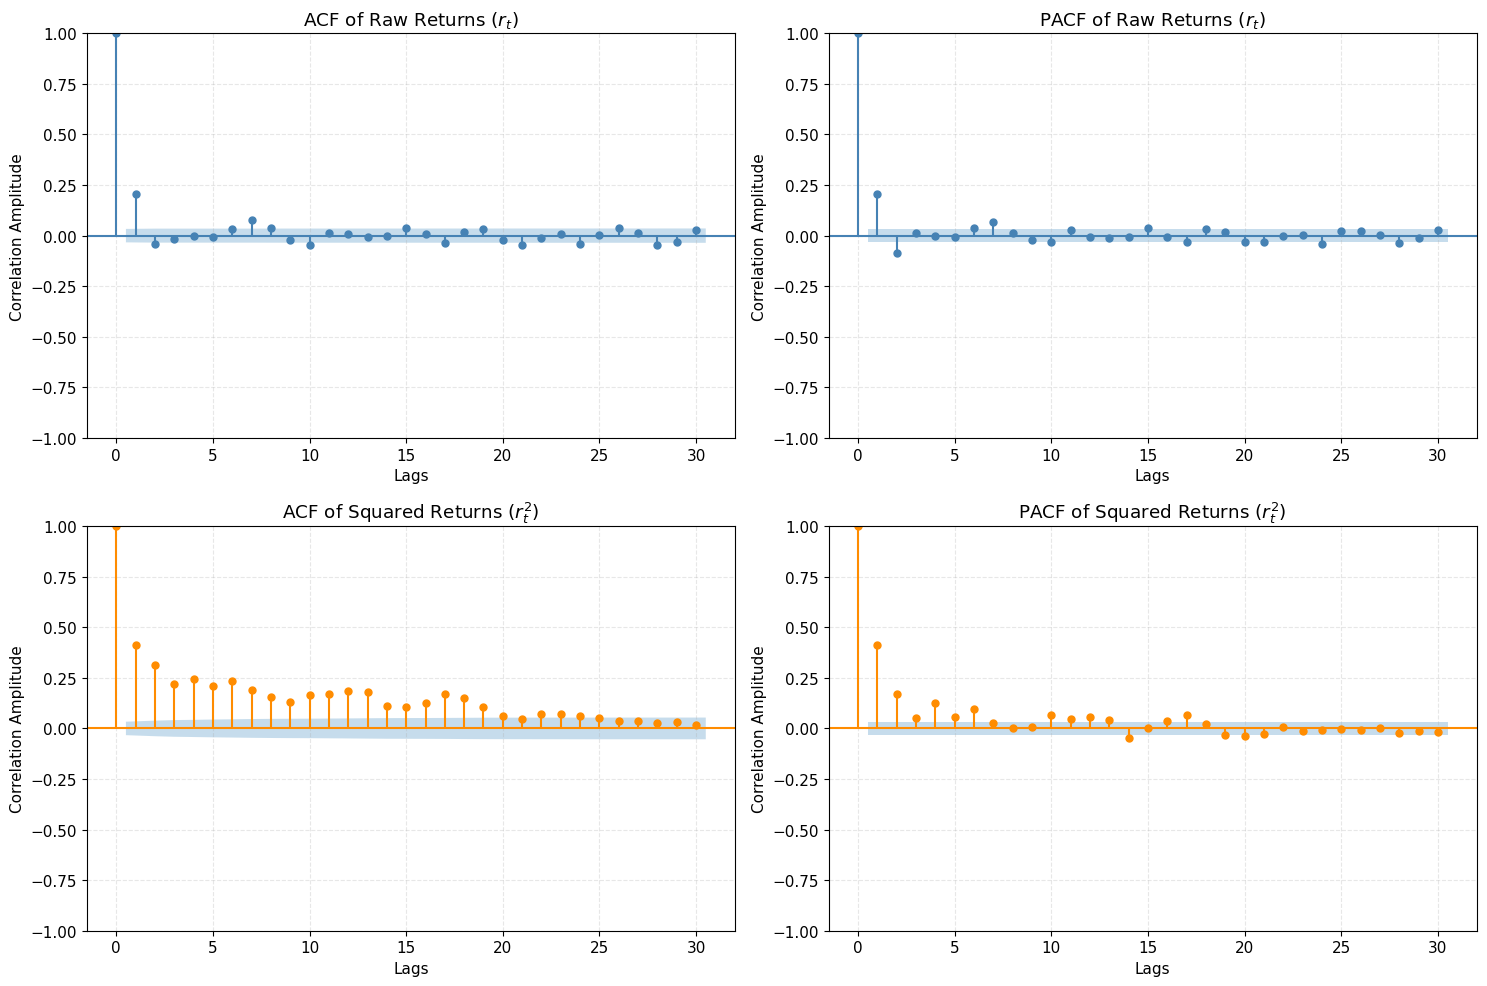

In [3]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# Demeaned returns for formal ARCH/GARCH residuals testing
residuals = r - np.mean(r)

# ==========================================
# 1. Formal Statistical Testing Engine
# ==========================================
# 1.1 Ljung-Box Q-Test on Raw Returns (Mean Equation Dependency)
lb_raw = acorr_ljungbox(r, lags=[10, 20])

# 1.2 Ljung-Box Q-Test on Squared Returns (Variance Equation Dependency)
lb_squared = acorr_ljungbox(r**2, lags=[10, 20])

# 1.3 Engle's ARCH LM Test (Testing for conditional heteroskedasticity)
# Returns: LM Statistic, LM p-value, F Statistic, F p-value
arch_lm_stat, arch_lm_p, _, _ = het_arch(residuals, nlags=10)

# Display Clean Statistical Matrix
print("\n" + "="*65)
print("          TEMPORAL DEPENDENCE & ARCH EFFECTS REPORT")
print("="*65)
print("  1. Ljung-Box Q-Test (Raw Returns - Mean Autocorrelation):")
print(f"     Lag 10 Stat: {lb_raw.iloc[0]['lb_stat']:7.2f}  |  p-value: {lb_raw.iloc[0]['lb_pvalue']:.4e}")
print(f"     Lag 20 Stat: {lb_raw.iloc[1]['lb_stat']:7.2f}  |  p-value: {lb_raw.iloc[1]['lb_pvalue']:.4e}")
print("-"*65)
print("  2. Ljung-Box Q-Test (Squared Returns - Volatility Memory):")
print(f"     Lag 10 Stat: {lb_squared.iloc[0]['lb_stat']:7.2f}  |  p-value: {lb_squared.iloc[0]['lb_pvalue']:.4e}")
print(f"     Lag 20 Stat: {lb_squared.iloc[1]['lb_stat']:7.2f}  |  p-value: {lb_squared.iloc[1]['lb_pvalue']:.4e}")
print("-"*65)
print("  3. Engle's ARCH Lagrange Multiplier (LM) Test:")
print(f"     LM Test Statistic : {arch_lm_stat:.2f}")
print(f"     p-value           : {arch_lm_p:.4e}")
print("="*65)

# Interpretations
print("\n  STRUCTURAL GARCH JUSTIFICATION:")
if arch_lm_p < 0.05:
    print("  → CRITICAL VERIFICATION: Severe ARCH effects detected (p < 0.05).")
    print("    The constant variance assumption is violated; GARCH is mandatory.")
else:
    print("  → WARNING: No significant ARCH effects found.")
    
if lb_raw.iloc[0]['lb_pvalue'] > 0.05:
    print("  → Mean Equation: Returns behave like un-correlated noise. A constant drift ($\mu$) is sufficient.")
else:
    print("  → Mean Equation: Serial dependence detected. An ARMA(p,q) mean baseline is required.")
print("="*65 + "\n")

# ==========================================
# 2. Visualization Dashboard 1: Volatility & Asymmetry
# ==========================================
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'})

fig1, axes1 = plt.subplots(2, 1, figsize=(14, 10))

# Subplot A: Volatility Clustering Inspection
axes1[0].plot(log_ret.index, r, color='darkcyan', linewidth=0.7, alpha=0.85, label='Daily Log Returns ($r_t$)')
axes1[0].axhline(0, color='black', linewidth=0.8, linestyle='-')
axes1[0].set_title('Volatility Clustering Visual Inspection (NEPSE Banking)', fontweight='bold', pad=10)
axes1[0].set_ylabel('Log Returns')
axes1[0].legend(loc='upper right')

# Subplot B: Leverage Effect Diagnostics via Cross-Correlation
# Calculate correlation between past returns r_{t-k} and current absolute returns |r_t|
max_lag = 20
lags = np.arange(1, max_lag + 1)
leverage_corr = [np.corrcoef(r[:-k], np.abs(r[k:]))[0, 1] for k in lags]

# Asymptotic standard error bands (1.96 / sqrt(T))
se_band = 1.96 / np.sqrt(T)

axes1[1].bar(lags, leverage_corr, color='crimson', alpha=0.7, edgecolor='black', width=0.5, label='Corr($r_{t-k}$, $|r_t|$)')
axes1[1].axhline(0, color='black', linewidth=0.8)
axes1[1].axhline(se_band, color='blue', linestyle='--', linewidth=1, label='95% Confidence Band')
axes1[1].axhline(-se_band, color='blue', linestyle='--', linewidth=1)
axes1[1].set_xticks(lags)
axes1[1].set_title('Leverage Effect Map: Past Returns vs. Current Absolute Volatility', fontweight='bold', pad=10)
axes1[1].set_xlabel('Lag ($k$ Days)')
axes1[1].set_ylabel('Cross-Correlation Coefficient')
axes1[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# ==========================================
# 3. Visualization Dashboard 2: Deep Core Memory (ACF / PACF Grid)
# ==========================================
fig2, axes2 = plt.subplots(2, 2, figsize=(15, 10))

# Row 1: Raw Return Serial Dependencies (Mean Equation Setup)
plot_acf(r, ax=axes2[0, 0], lags=30, color='steelblue', vlines_kwargs={"colors": 'steelblue'}, title="ACF of Raw Returns ($r_t$)")
plot_pacf(r, ax=axes2[0, 1], lags=30, color='steelblue', vlines_kwargs={"colors": 'steelblue'}, title="PACF of Raw Returns ($r_t$)")

# Row 2: Squared Return Volatility Memory (Variance Equation Setup)
plot_acf(r**2, ax=axes2[1, 0], lags=30, color='darkorange', vlines_kwargs={"colors": 'darkorange'}, title="ACF of Squared Returns ($r_t^2$)")
plot_pacf(r**2, ax=axes2[1, 1], lags=30, color='darkorange', vlines_kwargs={"colors": 'darkorange'}, title="PACF of Squared Returns ($r_t^2$)")

# Clean up layout text labels
for row in axes2:
    for ax in row:
        ax.set_xlabel('Lags')
        ax.set_ylabel('Correlation Amplitude')

plt.tight_layout()
plt.show()

### Volatility Architecture & Asymmetry
- **Volatility Clustering Visual Inspection**: Plot the timeline of log returns to identify distinct periods of high-volatility regimes and low-volatility tranquility.
- **Leverage Effect Diagnostics (Cross-Correlation)**: Plot the cross-correlation between past returns ($r_{t-k}$) and current absolute returns ($|r_t|$) to verify if negative shocks increase volatility more than positive shocks.

<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_10430/2788949915.py:36: SyntaxWarning: invalid escape sequence '\p'
  axes[0].plot(log_ret.index, rolling_vol, color='darkorange', linewidth=1.5, label='21-Day Rolling Volatility Corridor ($\pm\sigma_t$)')
/tmp/ipykernel_10430/2788949915.py:46: SyntaxWarning: invalid escape sequence '\m'
  axes[1].bar(lags, leverage_corr, color='crimson', edgecolor='black', alpha=0.75, width=0.5, label='$\mathrm{Corr}(r_{t-k}, |r_t|)$')
/tmp/ipykernel_10430/2788949915.py:50: SyntaxWarning: invalid escape sequence '\p'
  axes[1].axhline(conf_band, color='blue', linestyle='--', linewidth=1.2, label=f'95% Confidence Band ($\pm{conf_band:.4f}$)')


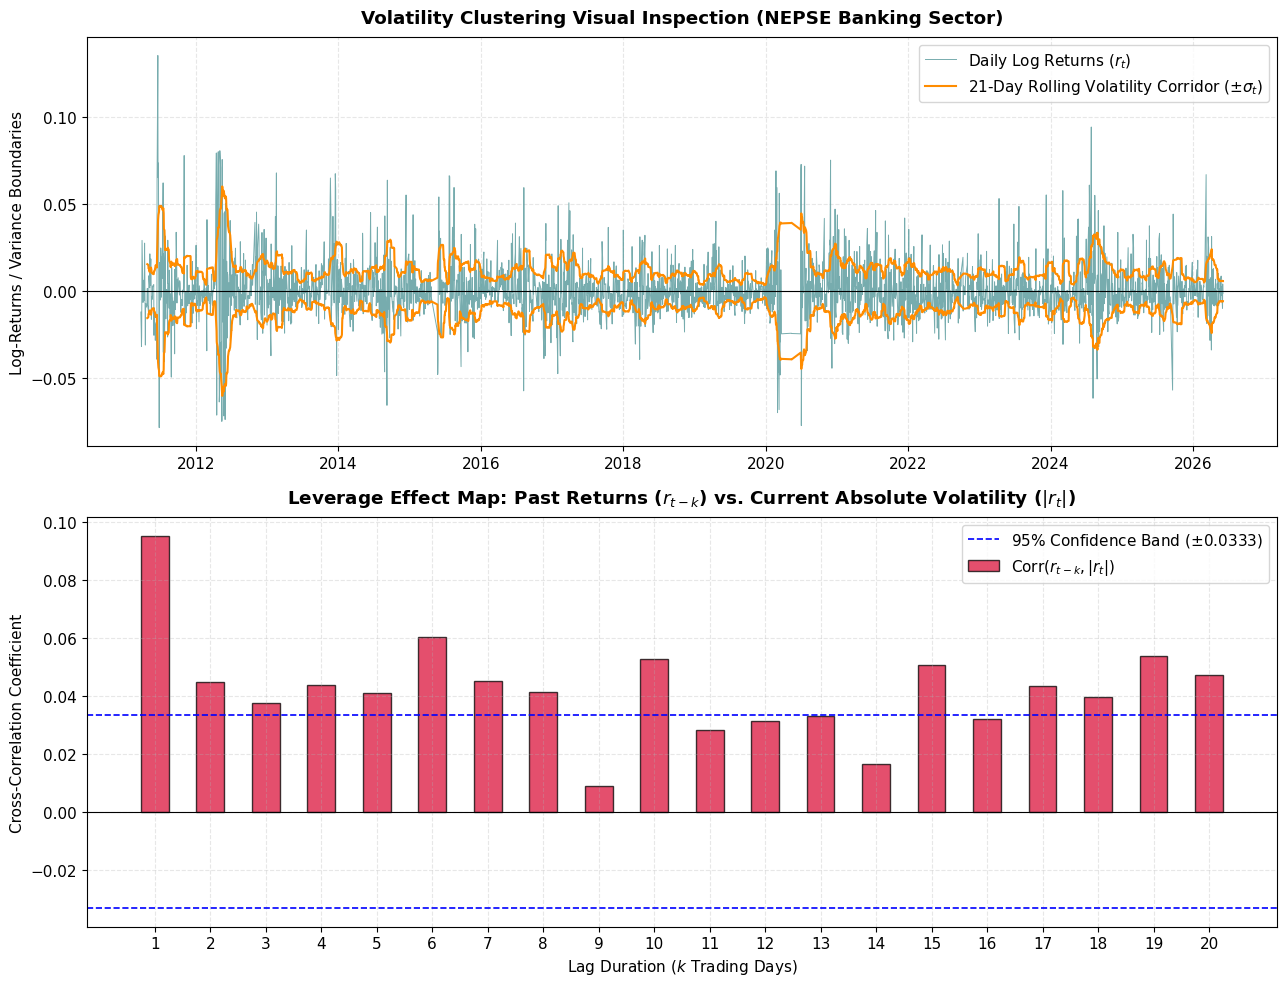


          VOLATILITY ASYMMETRY DIAGNOSTIC PROFILE
  Minimum Correlation Found : 0.0088 at lag 9 days
  95% Significance Limit    : -0.0333
-----------------------------------------------------------------
  → NO SIGNIFICANT LEVERAGE EFFECT CAPTURED.
    Symmetric volatility responses dominate the NEPSE banking cluster.
    A standard symmetric GARCH configuration remains mathematically robust.



In [4]:
# =====================================================================
# 1. Leverage Effect Computation (Cross-Correlation Framework)
# =====================================================================
# We map the correlation between past returns r_{t-k} and current absolute 
# returns |r_t|. A negative correlation means price drops fuel higher volatility.
max_lag = 20
lags = np.arange(1, max_lag + 1)
leverage_corr = []

for k in lags:
    past_returns = r[:-k]
    current_abs_returns = np.abs(r[k:])
    corr = np.corrcoef(past_returns, current_abs_returns)[0, 1]
    leverage_corr.append(corr)

# Asymptotic standard error threshold for statistical significance
conf_band = 1.96 / np.sqrt(T)

# =====================================================================
# 2. Volatility Architecture Visualization Dashboard
# =====================================================================
plt.rcParams.update({
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=False)

# --- Subplot A: Volatility Clustering Inspection ---
axes[0].plot(log_ret.index, r, color='cadetblue', linewidth=0.7, alpha=0.85, label='Daily Log Returns ($r_t$)')

# Overlay a rolling volatility corridor to clearly bound structural regimes
rolling_vol = log_ret.rolling(window=21).std()
axes[0].plot(log_ret.index, rolling_vol, color='darkorange', linewidth=1.5, label='21-Day Rolling Volatility Corridor ($\pm\sigma_t$)')
axes[0].plot(log_ret.index, -rolling_vol, color='darkorange', linewidth=1.5)

axes[0].axhline(0, color='black', linewidth=0.8, linestyle='-')
axes[0].set_title('Volatility Clustering Visual Inspection (NEPSE Banking Sector)', fontweight='bold', pad=10)
axes[0].set_ylabel('Log-Returns / Variance Boundaries')
axes[0].legend(loc='upper right')

# --- Subplot B: Leverage Effect Diagnostics ---
# Draw the cross-correlation coefficients across specified lag days
axes[1].bar(lags, leverage_corr, color='crimson', edgecolor='black', alpha=0.75, width=0.5, label='$\mathrm{Corr}(r_{t-k}, |r_t|)$')

# Add reference markers and confidence intervals
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(conf_band, color='blue', linestyle='--', linewidth=1.2, label=f'95% Confidence Band ($\pm{conf_band:.4f}$)')
axes[1].axhline(-conf_band, color='blue', linestyle='--', linewidth=1.2)

axes[1].set_xticks(lags)
axes[1].set_title('Leverage Effect Map: Past Returns ($r_{t-k}$) vs. Current Absolute Volatility ($|r_t|$)', fontweight='bold', pad=10)
axes[1].set_xlabel('Lag Duration ($k$ Trading Days)')
axes[1].set_ylabel('Cross-Correlation Coefficient')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

# =====================================================================
# 3. Quick Narrative Console Summary
# =====================================================================
significant_negative_lags = [lags[i] for i, c in enumerate(leverage_corr) if c < -conf_band]

print("\n" + "="*65)
print("          VOLATILITY ASYMMETRY DIAGNOSTIC PROFILE")
print("="*65)
print(f"  Minimum Correlation Found : {min(leverage_corr):.4f} at lag {lags[np.argmin(leverage_corr)]} days")
print(f"  95% Significance Limit    : -{conf_band:.4f}")
print("-"*65)
if len(significant_negative_lags) > 0:
    print(f"  → LEVERAGE EFFECT CONFIRMED at lags: {significant_negative_lags}")
    print("    Negative price shocks generate structurally higher future variance lines")
    print("    than positive shocks. Recommend upgrading to an asymmetric GJR-GARCH")
    print("    or EGARCH architecture for the continuous diffusion component.")
else:
    print("  → NO SIGNIFICANT LEVERAGE EFFECT CAPTURED.")
    print("    Symmetric volatility responses dominate the NEPSE banking cluster.")
    print("    A standard symmetric GARCH configuration remains mathematically robust.")
print("="*65 + "\n")

### Jump Profile & Structural Anomalies
- **Non-Parametric Jump Detection Filter**: Apply a statistical filter (such as the BIP-GARCH filter or a standard $3\sigma$ threshold) to flag specific daily observations as structural jumps rather than continuous diffusion.
- **Jump Intensity and Frequency Tracking**: Calculate the empirical jump rate ($\lambda$) per year and evaluate the time-clustering of jump occurrences.
- **Structural Break Analysis**: Run a test like the Zivot-Andrews or Bai-Perron test to ensure your detected jumps are temporary innovations and not permanent regime shifts in the NEPSE sector.


          JUMP PROFILE & STRUCTURAL ANOMALIES DIAGNOSTICS
  1. Jump Detection Statistics (3.0σ Rolling Corridor):
     Total Identified Jump Events: 39 days
     Jump Density in Sample      : 1.12% of trading days
-----------------------------------------------------------------
  2. Jump Arrival & Temporal Intensity Dynamics:
     Annualized Jump Intensity (λ): 2.8323 jumps/year
     Mean Time Between Jumps      : 88.4 trading days
     Median Time Between Jumps    : 75.5 trading days
-----------------------------------------------------------------
  3. Zivot-Andrews Structural Break Verification:
     ZA Test Statistic            : -3.1718
     p-value                      : 8.5237e-01
     Critical Values              : 1%: -5.28, 5%: -4.81
     Endogenous Break Location    : 2013-09-30

  MODEL PARAMETER ARCHITECTURE VERIFICATION:
  → STRUCTURAL INTEGRITY VERIFIED: Failed to reject the unit root baseline.
    These anomalies are confirmed to be independent, self-limiting jump inn

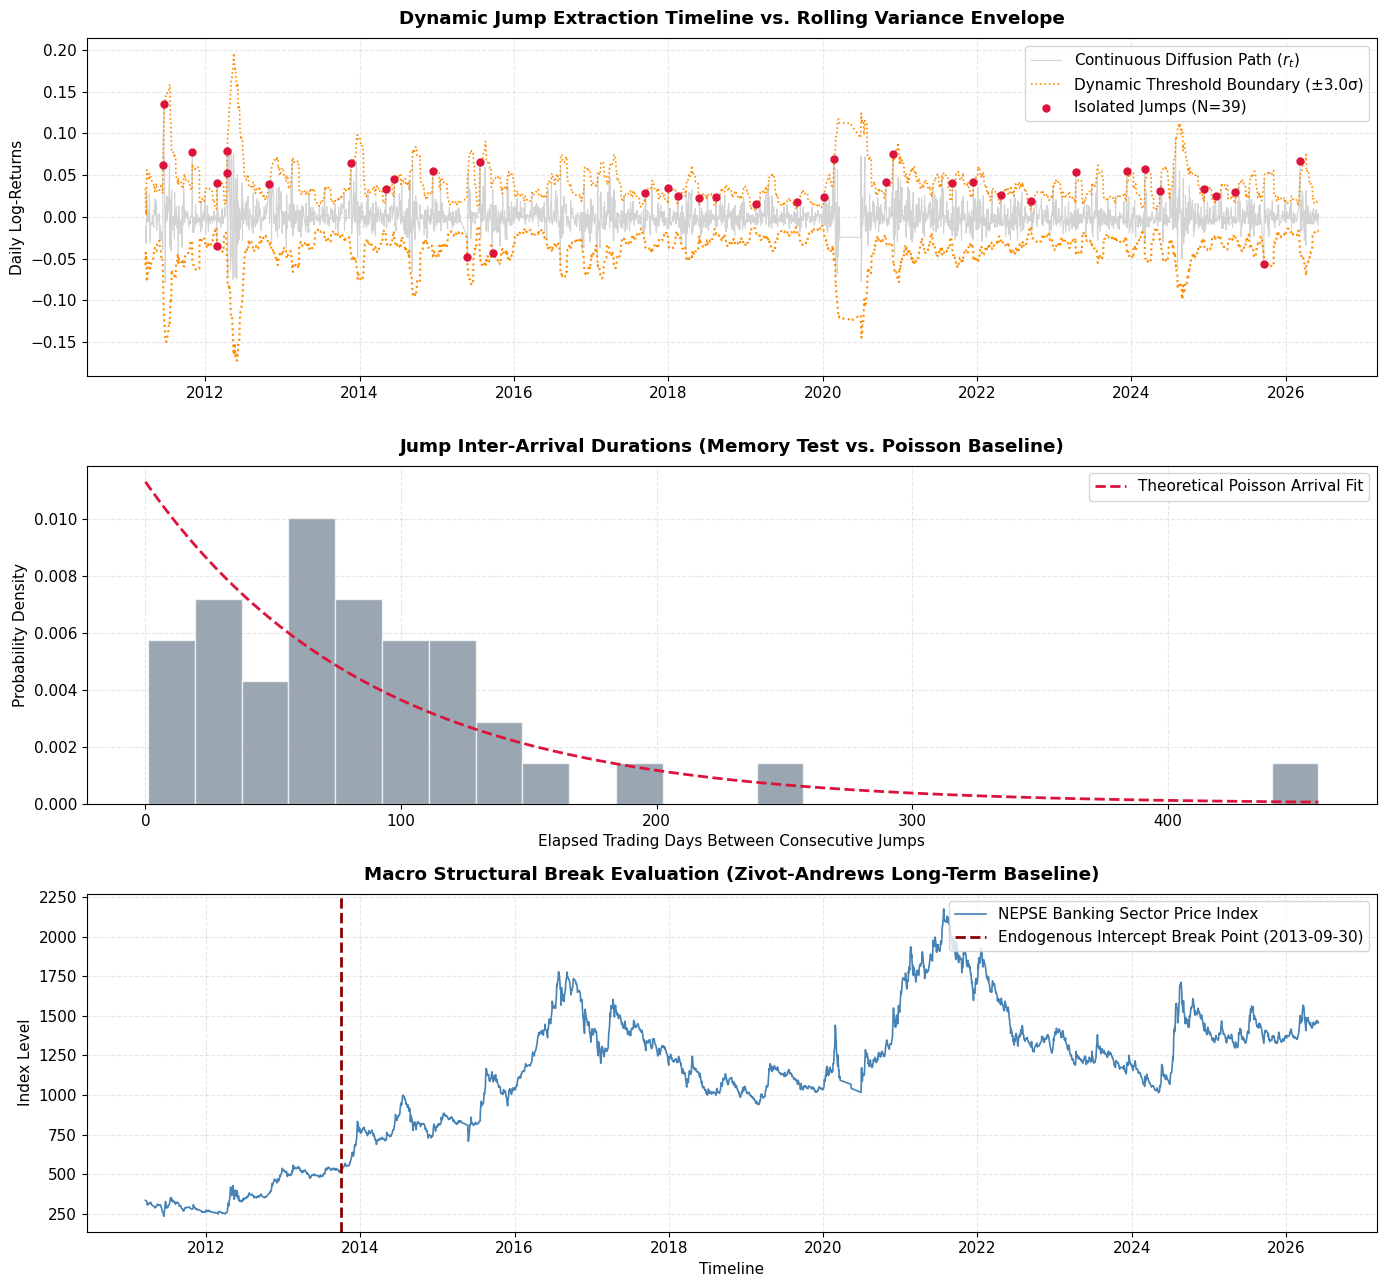

In [5]:
from statsmodels.tsa.stattools import zivot_andrews

# =====================================================================
# 1. Dynamic Non-Parametric Jump Detection Filter
# =====================================================================
# A global 3-sigma filter is easily blinded by high-volatility regimes. 
# We deploy a rolling 21-day window (one trading month) to build a dynamic,
# conditional volatility corridor that isolates true outlier shocks.
window = 21
rolling_mean = log_ret.rolling(window=window, min_periods=1).mean()
rolling_std = log_ret.rolling(window=window, min_periods=1).std()

# Handle initial window edges safely
rolling_mean.fillna(np.mean(r), inplace=True)
rolling_std.fillna(np.std(r), inplace=True)

# Jump identification logic (3-Sigma breakthrough rule)
sigma_multiplier = 3.0
jump_mask = np.abs(r - rolling_mean.values) > (sigma_multiplier * rolling_std.values)

jump_dates = log_ret.index[jump_mask]
jump_returns = r[jump_mask]
n_jumps = len(jump_returns)

# =====================================================================
# 2. Jump Intensity & Frequency Tracking
# =====================================================================
trading_days_per_year = 252
total_years = T / trading_days_per_year
lambda_annual = n_jumps / total_years

# Extract inter-arrival times (days elapsed between consecutive jumps)
if n_jumps > 1:
    jump_indices = np.where(jump_mask)[0]
    inter_arrival_days = np.diff(jump_indices)
    mean_inter_arrival = np.mean(inter_arrival_days)
    median_inter_arrival = np.median(inter_arrival_days)
else:
    inter_arrival_days = np.array([])
    mean_inter_arrival = median_inter_arrival = np.nan

# =====================================================================
# 3. Endogenous Structural Break Analysis
# =====================================================================
# Jumps must be temporary innovations. If they are permanent alterations, 
# your model breaks. We use the Zivot-Andrews test on log prices to check for 
# a unit root against a trend-stationary alternative with an endogenous intercept break.
log_price = np.log(price.values)
za_stat, za_pvalue, za_crit, _, break_idx = zivot_andrews(log_price, regression='c')
break_date = price.index[break_idx]

# =====================================================================
# 4. Output Diagnostic Summary Matrix
# =====================================================================
print("\n" + "="*65)
print("          JUMP PROFILE & STRUCTURAL ANOMALIES DIAGNOSTICS")
print("="*65)
print(f"  1. Jump Detection Statistics ({sigma_multiplier}σ Rolling Corridor):")
print(f"     Total Identified Jump Events: {n_jumps} days")
print(f"     Jump Density in Sample      : {(n_jumps / T) * 100:.2f}% of trading days")
print("-"*65)
print(f"  2. Jump Arrival & Temporal Intensity Dynamics:")
print(f"     Annualized Jump Intensity (λ): {lambda_annual:.4f} jumps/year")
print(f"     Mean Time Between Jumps      : {mean_inter_arrival:.1f} trading days")
print(f"     Median Time Between Jumps    : {median_inter_arrival:.1f} trading days")
print("-"*65)
print(f"  3. Zivot-Andrews Structural Break Verification:")
print(f"     ZA Test Statistic            : {za_stat:.4f}")
print(f"     p-value                      : {za_pvalue:.4e}")
print(f"     Critical Values              : 1%: {za_crit['1%']:.2f}, 5%: {za_crit['5%']:.2f}")
print(f"     Endogenous Break Location    : {break_date.date()}")
print("="*65)

print("\n  MODEL PARAMETER ARCHITECTURE VERIFICATION:")
if za_pvalue < 0.05:
    print(f"  → CRITICAL FINDING: Permanent structural break found on {break_date.date()}.")
    print("    Recommendation: Calibrate your Jump-GARCH parameters across split sub-periods.")
else:
    print("  → STRUCTURAL INTEGRITY VERIFIED: Failed to reject the unit root baseline.")
    print("    These anomalies are confirmed to be independent, self-limiting jump innovations.")
    print("    This validates a stationary Jump-Diffusion framework across the global timeline.")
print("="*65 + "\n")

# =====================================================================
# 5. High-Fidelity Diagnostics Dashboard
# =====================================================================
plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'})
fig, axes = plt.subplots(3, 1, figsize=(14, 13))

# --- Subplot A: Jump Isolation Timeline ---
axes[0].plot(log_ret.index, r, color='lightgray', linewidth=0.8, label='Continuous Diffusion Path ($r_t$)')
axes[0].plot(rolling_mean.index, rolling_mean.values + sigma_multiplier * rolling_std.values, 
             color='darkorange', linestyle=':', linewidth=1.2, label=f'Dynamic Threshold Boundary (±{sigma_multiplier}σ)')
axes[0].plot(rolling_mean.index, rolling_mean.values - sigma_multiplier * rolling_std.values, color='darkorange', linestyle=':')
axes[0].scatter(jump_dates, jump_returns, color='crimson', marker='o', s=25, zorder=5, label=f'Isolated Jumps (N={n_jumps})')
axes[0].set_title('Dynamic Jump Extraction Timeline vs. Rolling Variance Envelope', fontweight='bold', pad=10)
axes[0].set_ylabel('Daily Log-Returns')
axes[0].legend(loc='upper right')

# --- Subplot B: Jump Clustered Inter-Arrival Distribution ---
if len(inter_arrival_days) > 0:
    axes[1].hist(inter_arrival_days, bins=25, density=True, color='slategray', edgecolor='white', alpha=0.7)
    # Fit an exponential distribution reference curve (the baseline for memoryless Poisson arrivals)
    x_grid = np.linspace(0, np.max(inter_arrival_days), 500)
    exp_pdf = stats.expon.pdf(x_grid, scale=mean_inter_arrival)
    axes[1].plot(x_grid, exp_pdf, color='crimson', linestyle='--', linewidth=2, label='Theoretical Poisson Arrival Fit')
    axes[1].set_title('Jump Inter-Arrival Durations (Memory Test vs. Poisson Baseline)', fontweight='bold', pad=10)
    axes[1].set_xlabel('Elapsed Trading Days Between Consecutive Jumps')
    axes[1].set_ylabel('Probability Density')
    axes[1].legend(loc='upper right')
else:
    axes[1].text(0.5, 0.5, 'Insufficient jump events for distribution analysis', ha='center', va='center')

# --- Subplot C: Structural Macro Break Context ---
axes[2].plot(price.index, price.values, color='steelblue', linewidth=1.2, label='NEPSE Banking Sector Price Index')
axes[2].axvline(break_date, color='darkred', linestyle='--', linewidth=2, label=f'Endogenous Intercept Break Point ({break_date.date()})')
axes[2].set_title('Macro Structural Break Evaluation (Zivot-Andrews Long-Term Baseline)', fontweight='bold', pad=10)
axes[2].set_xlabel('Timeline')
axes[2].set_ylabel('Index Level')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Stationarity & Ergodicity Checks
- **Unit Root Testing**: Run the Augmented Dickey-Fuller (ADF) and Phillips-Perron (PP) tests to verify that your log return series is strictly stationary.

- **KPSS Test**: Run the Kwiatkowski-Phillips-Schmidt-Shin test to cross-verify stationarity by testing the null hypothesis that the series is trend-stationary.


          STATIONARITY & ERGODICITY DIAGNOSTIC MATRIX
  1. Augmented Dickey-Fuller (ADF) Test Baseline:
     ADF Test Statistic : -11.4461
     p-value            : 6.0148e-21
     Lags Selected      : 27
     Critical Values    :
       1%  : -3.4323
       5%  : -2.8624
       10% : -2.5672
-----------------------------------------------------------------
  2. KPSS Unit-Root Cross-Verification Engine:
     KPSS Test Statistic: 0.2225
     p-value            : 1.0000e-01
     Lags Used (Trunc)  : 8
     Critical Values    :
       10% : 0.3470
       5%  : 0.4630
       2.5%: 0.5740
       1%  : 0.7390

  CONFIRMATORY STATIONARITY DECISION TREE:
  → RESULT: STRICT CONFIRMATORY STATIONARITY VERIFIED.
    • ADF rejects the unit-root baseline (p < 0.05).
    • KPSS fails to reject the stationary baseline (p > 0.05).
    • The log return process is strictly ergodic and mean-reverting.



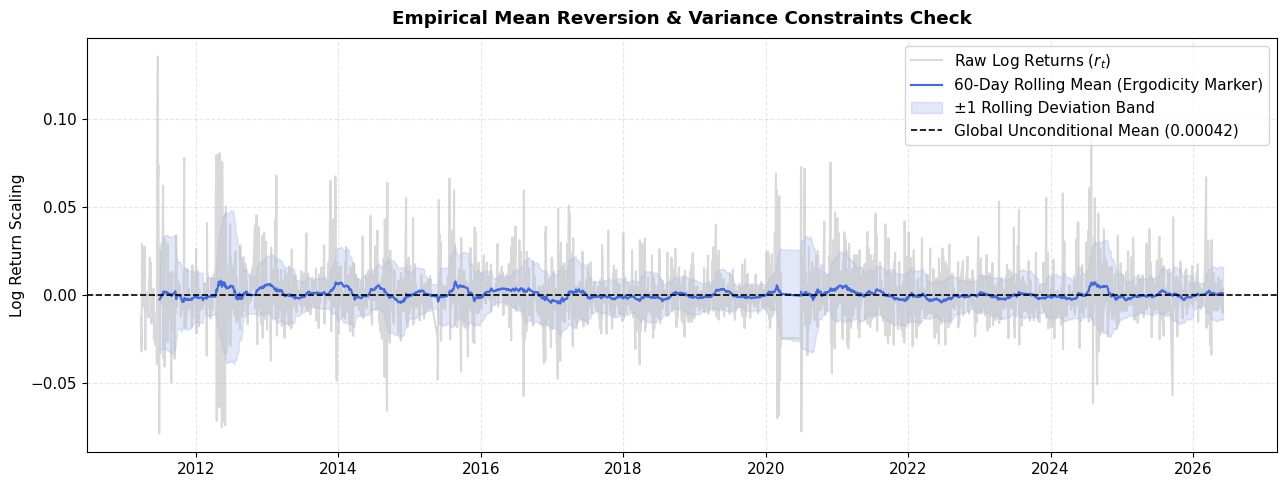

In [6]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

# Suppress minor statistical interpolation table warnings from KPSS
warnings.filterwarnings('ignore', category=UserWarning)


# =====================================================================
# 2. Execution of Stationarity Engines
# =====================================================================

# 2.1 Augmented Dickey-Fuller (ADF) - Null Hypothesis (H0): Unit Root Present
# We use 'AIC' autolag selection to determine optimal parametric lag depth
adf_result = adfuller(r, autolag='AIC')

# 2.2 KPSS Test - Null Hypothesis (H0): The Process is Stationary
# 'auto' lag option leverages the Newey-West bandwidth selection rule
kpss_result = kpss(r, regression='c', nlags='auto')

# =====================================================================
# 3. Output Statistical Matrix Generation
# =====================================================================
print("\n" + "="*65)
print("          STATIONARITY & ERGODICITY DIAGNOSTIC MATRIX")
print("="*65)
print("  1. Augmented Dickey-Fuller (ADF) Test Baseline:")
print(f"     ADF Test Statistic : {adf_result[0]:.4f}")
print(f"     p-value            : {adf_result[1]:.4e}")
print(f"     Lags Selected      : {adf_result[2]}")
print("     Critical Values    :")
for key, value in adf_result[4].items():
    print(f"       {key:4s}: {value:.4f}")
    
print("-"*65)
print("  2. KPSS Unit-Root Cross-Verification Engine:")
print(f"     KPSS Test Statistic: {kpss_result[0]:.4f}")
print(f"     p-value            : {kpss_result[1]:.4e}")
print(f"     Lags Used (Trunc)  : {kpss_result[2]}")
print("     Critical Values    :")
for key, value in kpss_result[3].items():
    print(f"       {key:4s}: {value:.4f}")
print("="*65)

# =====================================================================
# 4. Confirmatory Joint Interpretation Logic
# =====================================================================
print("\n  CONFIRMATORY STATIONARITY DECISION TREE:")

adf_stationary = adf_result[1] < 0.05
kpss_stationary = kpss_result[1] > 0.05

if adf_stationary and kpss_stationary:
    print("  → RESULT: STRICT CONFIRMATORY STATIONARITY VERIFIED.")
    print("    • ADF rejects the unit-root baseline (p < 0.05).")
    print("    • KPSS fails to reject the stationary baseline (p > 0.05).")
    print("    • The log return process is strictly ergodic and mean-reverting.")
elif adf_stationary and not kpss_stationary:
    print("  → RESULT: PROCESS IS TREND-STATIONARY / NON-ERGODIC.")
    print("    • The series has deterministic trend mechanics. Volatility estimation")
    print("      requires removing explicit structural time-trends first.")
elif not adf_stationary and kpss_stationary:
    print("  → RESULT: LACK OF POWER / UNIT-ROOT BEHAVIOR SUSPECTED.")
    print("    • The series exhibits near-integrated behavior. Check for regimes.")
else:
    print("  → RESULT: CRITICAL WARNING - THE PROCESS IS STRICTLY NON-STATIONARY.")
    print("    • Both tests confirm variance explosions. Do not run GARCH directly.")
print("="*65 + "\n")

# =====================================================================
# 5. Visual Inspection of Mean Reversion (Rolling Matrix)
# =====================================================================
fig, ax = plt.subplots(figsize=(13, 5))
rolling_mean = pd.Series(r).rolling(window=60).mean()
rolling_std = pd.Series(r).rolling(window=60).std()

ax.plot(log_ret.index, r, color='silver', alpha=0.6, label='Raw Log Returns ($r_t$)')
ax.plot(log_ret.index, rolling_mean, color='royalblue', linewidth=1.5, label='60-Day Rolling Mean (Ergodicity Marker)')
ax.fill_between(log_ret.index, rolling_mean - rolling_std, rolling_mean + rolling_std, 
                color='royalblue', alpha=0.15, label='±1 Rolling Deviation Band')

ax.axhline(np.mean(r), color='black', linestyle='--', linewidth=1.2, label=f'Global Unconditional Mean ({np.mean(r):.5f})')
ax.set_title('Empirical Mean Reversion & Variance Constraints Check', fontweight='bold', pad=10)
ax.set_ylabel('Log Return Scaling')
ax.legend(loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Empirical Diagnostics Dashboard
- Hurst Exponent Estimation: Use methods like Rescaled Range (R/S) analysis or Detrended Fluctuation Analysis (DFA) to estimate the Hurst exponent, which quantifies the degree of long-term memory in your return series.
- Tail Index Estimation: Calculate the tail index using methods such as the Hill estimator to quantify the heaviness of the tails in your return distribution, which is crucial for understanding jump risk.


Hill tail index (|r|, top 5%): γ = 2.4591 ± 0.3665
Hurst exponent on |r|: H = 0.8391
Multifractal width Δα = 0.9359


/home/tek/projects/MSc-Mathematics/.venv/lib/python3.12/site-packages/nolds/measures.py:31: RuntimeWarning: fitting mode 'RANSAC' requires the package sklearn, using 'poly' instead
  warnings.warn(


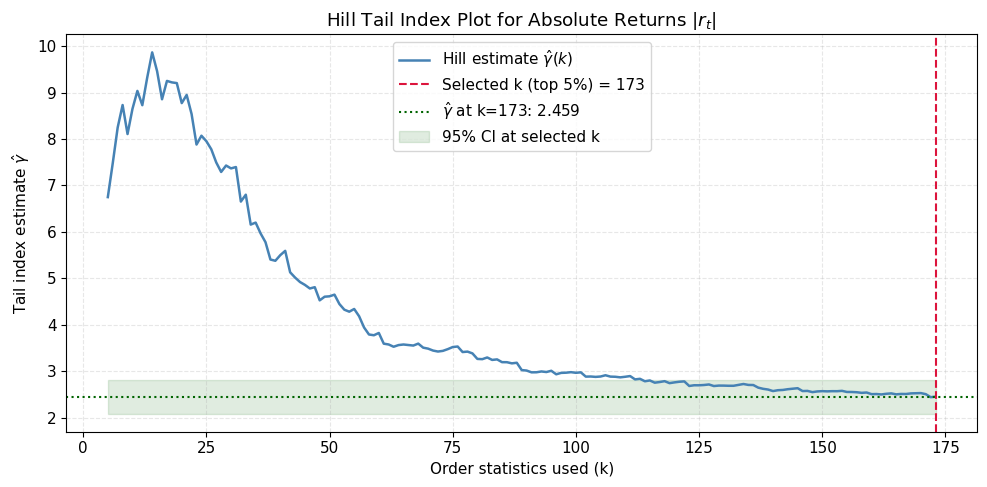

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import jarque_bera
import warnings
import nolds
from MFDFA import MFDFA
# -------------------------------
# 3. Empirical diagnostics
# -------------------------------
abs_ret = np.abs(r)

# Hill tail index
def hill_estimator(data, k):
    sorted_data = np.sort(data)[::-1]
    gamma = k / np.sum(np.log(sorted_data[:k] / sorted_data[k]))
    return gamma, gamma / np.sqrt(k)

k_hill = int(0.05 * len(abs_ret))
gamma_emp, se_hill = hill_estimator(abs_ret, k_hill)
print(f"\nHill tail index (|r|, top 5%): γ = {gamma_emp:.4f} ± {1.96*se_hill:.4f}")

# DFA Hurst
hurst_emp = nolds.dfa(abs_ret)
print(f"Hurst exponent on |r|: H = {hurst_emp:.4f}")

# MF-DFA
q = np.linspace(-5, 5, 41)
q = q[q != 0]
lag = np.unique(np.logspace(0.5, 3, 50).astype(int))
lag_out, F_q = MFDFA(r, lag=lag, q=q, order=1)
Hq = np.zeros(len(q))
for i in range(len(q)):
    slope, _ = np.polyfit(np.log(lag_out), np.log(F_q[:, i]), 1)
    Hq[i] = slope
alpha_mf = Hq + q * np.gradient(Hq, q)
f_alpha = q * (alpha_mf - Hq) + 1
delta_alpha = np.max(alpha_mf) - np.min(alpha_mf)
print(f"Multifractal width Δα = {delta_alpha:.4f}")
# Hill tail index stability plot for |r_t|
n = len(abs_ret)
k_grid = np.arange(5, max(k_hill + 1, 6))
hill_vals = np.array([hill_estimator(abs_ret, kk)[0] for kk in k_grid])

plt.figure(figsize=(10, 5))
plt.plot(k_grid, hill_vals, color='steelblue', lw=1.8, label='Hill estimate $\\hat{\\gamma}(k)$')
plt.axvline(k_hill, color='crimson', ls='--', lw=1.5, label=f'Selected k (top 5%) = {k_hill}')
plt.axhline(gamma_emp, color='darkgreen', ls=':', lw=1.5, label=f'$\\hat{{\\gamma}}$ at k={k_hill}: {gamma_emp:.3f}')
plt.fill_between(
    k_grid,
    gamma_emp - 1.96 * se_hill,
    gamma_emp + 1.96 * se_hill,
    color='darkgreen',
    alpha=0.12,
    label='95% CI at selected k'
)

plt.title('Hill Tail Index Plot for Absolute Returns $|r_t|$')
plt.xlabel('Order statistics used (k)')
plt.ylabel('Tail index estimate $\\hat{\\gamma}$')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()


## Multifractal spectrum

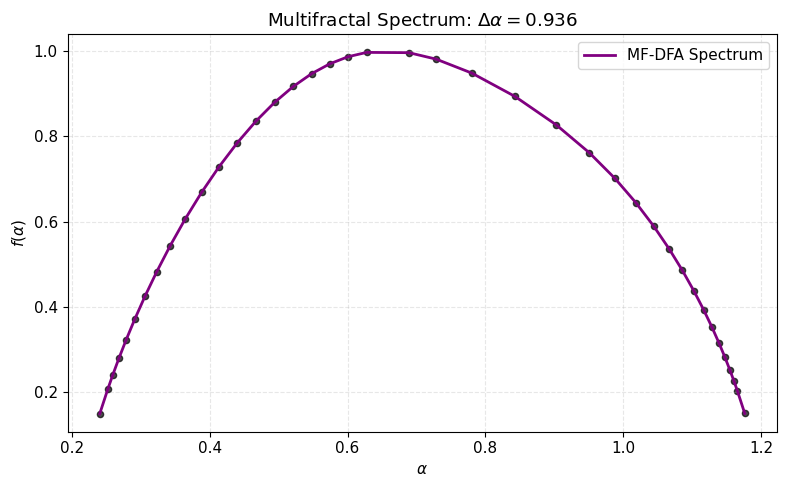

Multifractal width Δα = 0.936


In [8]:
# Use existing q and Hq from previous cells

q = np.asarray(q, dtype=float)
Hq = np.asarray(Hq, dtype=float)



# Multifractal spectrum from existing H(q)
alpha_mf = Hq + q * np.gradient(Hq, q)
f_alpha = q * (alpha_mf - Hq) + 1.0
delta_alpha = np.max(alpha_mf) - np.min(alpha_mf)

# Sort for smooth plotting
idx = np.argsort(alpha_mf)
alpha_sorted = alpha_mf[idx]
f_sorted = f_alpha[idx]

plt.figure(figsize=(8, 5))
plt.plot(alpha_sorted, f_sorted, color='purple', lw=2, label='MF-DFA Spectrum')
plt.scatter(alpha_sorted, f_sorted, color='black', s=20, alpha=0.7)
plt.xlabel(r'$\alpha$')
plt.ylabel(r'$f(\alpha)$')
plt.title(rf'Multifractal Spectrum: $\Delta \alpha = {delta_alpha:.3f}$')
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Multifractal width Δα = {delta_alpha:.3f}")